### connectin n importin

In [ ]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
db_path = "/Users/abdul/OneDrive/Desktop/dev/invoiceML/data/inventory.db"
conn = sqlite3.connect(db_path)
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


### explorin

In [18]:
for table in tables['name']:
    print(f"Table: {table}")
    df = pd.read_sql_query(f"SELECT * FROM {table} limit 2", conn)
    display(df)

Table: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1


Table: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP


Table: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None


Table: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01


Table: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31


In [19]:
ven_invoices = pd.read_sql_query("SELECT * FROM vendor_invoice", conn)
ven_invoices.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN


### relation bw quantity freight and dollars (linear)

In [20]:
ven_invoices[['Quantity', 'Freight', 'Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


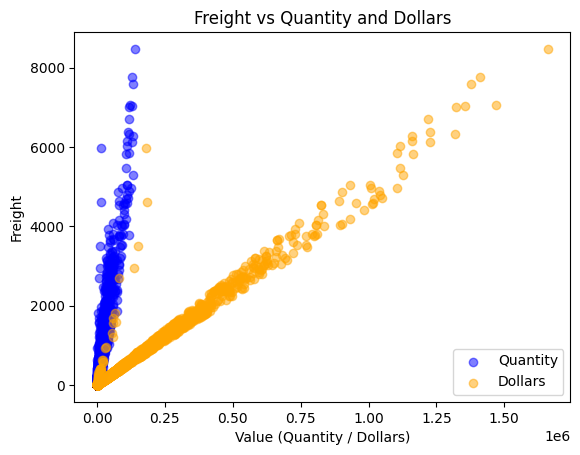

In [ ]:
# 1. Plot Quantity vs Freight (Blue)
plt.scatter(ven_invoices['Quantity'], ven_invoices['Freight'], 
            color='blue', label='Quantity', alpha=0.5)

# 2. Plot Dollars vs Freight (Orange) on the same graph
plt.scatter(ven_invoices['Dollars'], ven_invoices['Freight'], 
            color='orange', label='Dollars', alpha=0.5)

# 3. Add details
plt.ylabel('Freight')
plt.xlabel('Value (Quantity / Dollars)')
plt.title('Freight vs Quantity and Dollars')
plt.legend() # This shows the color key

plt.show()

### bulk order means low freight

In [24]:
ven_invoices['freight_per_unit'] = ven_invoices['Freight'] / ven_invoices['Quantity']
low_quantity = ven_invoices['Quantity'].quantile(0.25)
high_quantity = ven_invoices['Quantity'].quantile(0.75)
print(low_quantity)
print(high_quantity)

83.0
5100.5


In [ ]:
ven_invoices.loc[ven_invoices['Quantity'] < low_quantity, 'freight_per_unit'].mean()

np.float64(0.09489854253138316)

In [25]:
ven_invoices.loc[ven_invoices['Quantity'] > high_quantity, 'freight_per_unit'].mean()

np.float64(0.049077654690759046)